In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

40000
40000


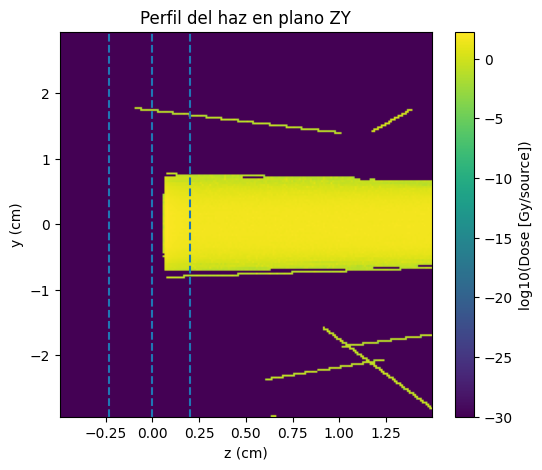

In [12]:
ny = 200
nz = 200

valores = []
leer = False

with open("perfil_dose_zy.out", "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        if linea.strip().startswith("hc:"):
            leer = True
            continue
        if leer:
            if linea.strip() == "":
                continue
            for p in linea.split():
                try:
                    valores.append(float(p))
                    if len(valores) == ny * nz:
                        leer = False
                        break
                except:
                    pass
        if len(valores) == ny * nz:
            break

data = np.array(valores)

print(len(data))
print(ny * nz)

dose = data.reshape((ny, nz))

y = np.linspace(2.94, -2.94, ny)
z = np.linspace(-0.495, 1.495, nz)

plt.figure(figsize=(6,5))

plt.imshow(np.log10(dose + 1e-30),
           extent=[z.min(), z.max(), y.min(), y.max()],
           aspect='auto',
           origin='lower')
plt.axvline(-0.23, linestyle='--')
plt.axvline(0, linestyle='--')
plt.axvline(0.2, linestyle='--')
plt.colorbar(label="log10(Dose [Gy/source])")
plt.xlabel("z (cm)")
plt.ylabel("y (cm)")
plt.title("Perfil del haz en plano ZY")

plt.show()

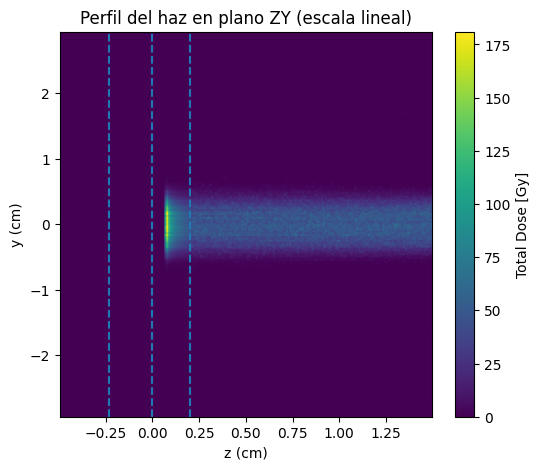

In [11]:
ny = 200
nz = 200

valores = []
leer = False

with open("perfil_dose_zy.out", "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        if linea.strip().startswith("hc:"):
            leer = True
            continue
        if leer:
            if linea.strip() == "":
                continue
            for p in linea.split():
                try:
                    valores.append(float(p))
                    if len(valores) == ny * nz:
                        leer = False
                        break
                except:
                    pass
        if len(valores) == ny * nz:
            break

data = np.array(valores)

dose = data.reshape((ny, nz))

y = np.linspace(2.94, -2.94, ny)
z = np.linspace(-0.495, 1.495, nz)

plt.figure(figsize=(6,5))

plt.imshow(dose,
           extent=[z.min(), z.max(), y.min(), y.max()],
           aspect='auto',
           origin='lower')

plt.axvline(-0.23, linestyle='--')
plt.axvline(0, linestyle='--')
plt.axvline(0.2, linestyle='--')

plt.colorbar(label="Total Dose [Gy]")
plt.xlabel("z (cm)")
plt.ylabel("y (cm)")
plt.title("Perfil del haz en plano ZY (escala lineal)")

plt.show()

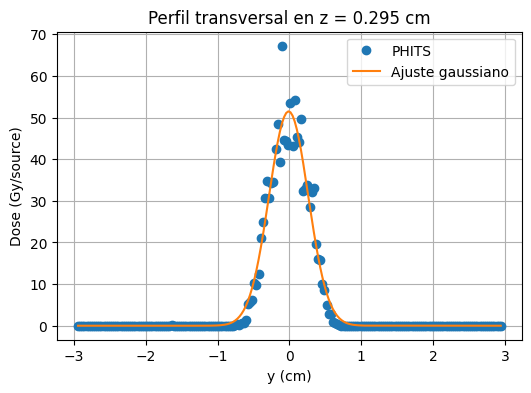

A = 51.50512566962132
y0 = -0.010781835878572586
sigma = 0.272423091748035
FWHM = 0.6415563810666224


In [13]:
ny = 200
nz = 200

valores = []
leer = False

with open("perfil_dose_zy.out", "r", encoding="utf-8", errors="ignore") as f:
    for linea in f:
        if linea.strip().startswith("hc:"):
            leer = True
            continue
        if leer:
            if linea.strip() == "":
                continue
            for p in linea.split():
                try:
                    valores.append(float(p))
                    if len(valores) == ny * nz:
                        break
                except:
                    pass
        if len(valores) == ny * nz:
            break

dose = np.array(valores).reshape((ny, nz))

y = np.linspace(2.94, -2.94, ny)
z = np.linspace(-0.495, 1.495, nz)

z_objetivo = 0.3
iz = np.argmin(np.abs(z - z_objetivo))
perfil_y = dose[:, iz]

def gauss(y, A, y0, sigma):
    return A * np.exp(-(y - y0)**2 / (2 * sigma**2))

p0 = [perfil_y.max(), 0.0, 0.5]
popt, _ = curve_fit(gauss, y, perfil_y, p0=p0)

plt.figure(figsize=(6,4))
plt.plot(y, perfil_y, 'o', label='PHITS')
plt.plot(y, gauss(y, *popt), '-', label='Ajuste gaussiano')
plt.xlabel("y (cm)")
plt.ylabel("Dose (Gy/source)")
plt.title(f"Perfil transversal en z = {z[iz]:.3f} cm")
plt.legend()
plt.grid()
plt.show()

print("A =", popt[0])
print("y0 =", popt[1])
print("sigma =", popt[2])
print("FWHM =", 2.355 * popt[2])

In [8]:
z_objetivo = 0.0
iz = np.argmin(np.abs(z - z_objetivo))

print("z usado =", z[iz])

z usado = -0.0050000000000000044
